In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
print(df.shape)
print(df.columns)
print(df.columns.tolist())
print(df.nunique())


(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [6]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [7]:
print(df.index)

RangeIndex(start=0, stop=891, step=1)


## 1. Number of passengers by gender — Pie Chart
Shows the *proportion* (share of the whole) of male vs female passengers, instead of raw bar heights.

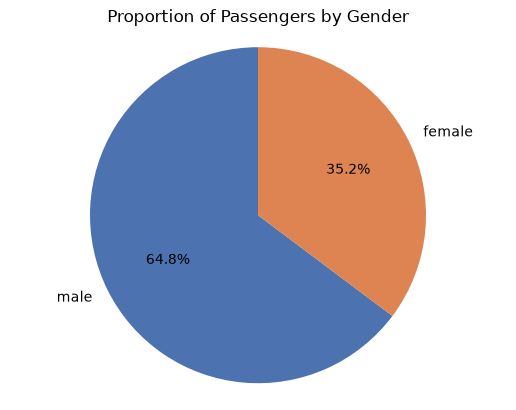

In [8]:
gender_count = df["sex"].value_counts()

plt.pie(gender_count.values, labels=gender_count.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90)
plt.title("Proportion of Passengers by Gender")
plt.axis("equal")
plt.show()


## 2. Number of passengers by class — Horizontal Bar Chart
Same data as before (counts per class), but flipped to horizontal bars — useful when category labels are longer or you want to emphasize ranking.

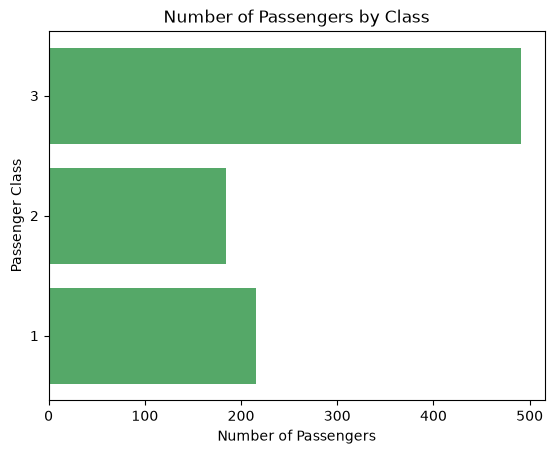

In [9]:
class_count = df["pclass"].value_counts().sort_index()

plt.barh(class_count.index.astype(str), class_count.values, color="#55A868")
plt.title("Number of Passengers by Class")
plt.xlabel("Number of Passengers")
plt.ylabel("Passenger Class")
plt.show()


## 3. Age distribution — Box Plot (by survival)
Instead of a plain histogram, this shows the spread, median, and outliers of age, split by whether the passenger survived.

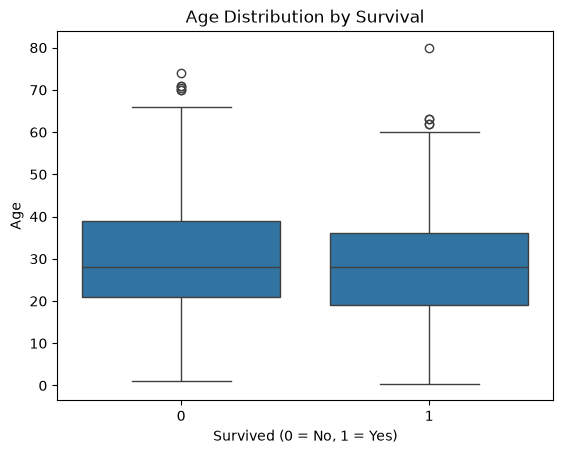

In [10]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


## 4. Age vs Fare — Hexbin Plot
Instead of a scatterplot (one dot per passenger), a hexbin plot bins points into hexagonal cells and colors them by density — clearer when there are many overlapping points.

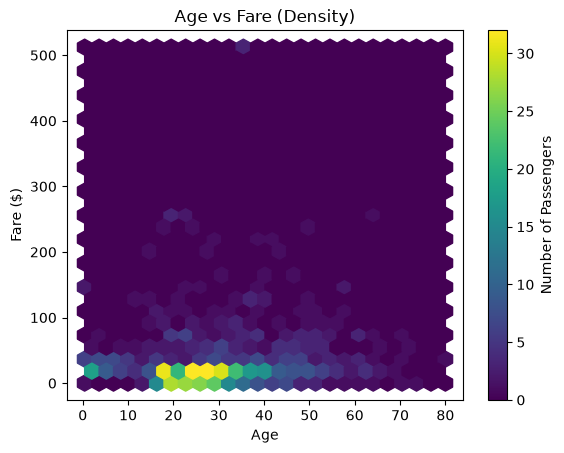

In [11]:
age_fare = df[["age", "fare"]].dropna()

plt.hexbin(age_fare["age"], age_fare["fare"], gridsize=25, cmap="viridis")
plt.colorbar(label="Number of Passengers")
plt.title("Age vs Fare (Density)")
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.show()


## Bonus: Survival rate by class — Heatmap
A heatmap of survival rate across class and gender, showing patterns a single chart can't.

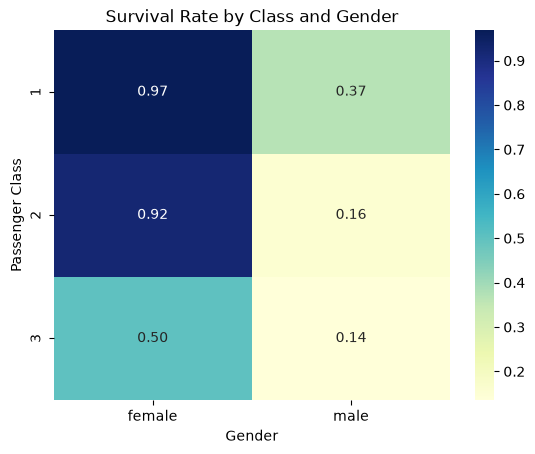

In [12]:
pivot = df.pivot_table(values="survived", index="pclass", columns="sex", aggfunc="mean")

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Gender")
plt.ylabel("Passenger Class")
plt.show()


## Preprocessing (unchanged)
Handling missing data and encoding categorical variables for modeling.

In [13]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])
